# U‑Net–Based Cell Segmentation with Morphological Analysis






This notebook presents a complete deep‑learning workflow for biomedical cell
segmentation using a U‑Net architecture. The pipeline integrates data
preparation, preprocessing, augmentation, model training, and quantitative
evaluation to provide a clear and reproducible approach to semantic segmentation
in microscopy imaging.

Beyond pixel‑wise segmentation, the notebook extends the analysis to the
instance level by converting the predicted probability maps into calibrated
binary masks and applying connected‑component labelling. Geometric features such
as area, perimeter, eccentricity, and circularity are then extracted to assess
cell‑level morphology. This demonstrates how semantic segmentation outputs can
support downstream quantitative tasks, including cell counting, shape analysis,
and population‑level comparisons with ground‑truth annotations.


# Dataset and Data Acquisition

The experiments in this notebook use the BCCD dataset, published on Kaggle by Jeet B. Lahiri. The dataset contains microscopy images of various cells together with corresponding pixel‑level annotations for semantic segmentation. The images and masks were downloaded directly from the Kaggle dataset page and are not included in this repository.

The dataset is distributed under the MIT Licence. Users should refer to the original Kaggle page for full licence terms and authorship information.

In [ ]:
# Mount Google Drive to access the dataset stored in user's Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract the dataset ZIP file directly from Google Drive into the Colab environment.
import zipfile

zip_path = "/content/drive/MyDrive/BCCD_Dataset_With_Mask.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("bccd")

print("Dataset extracted to: bccd/")


Dataset extracted to: bccd/


# Data Preprocessing

This section prepares the dataset for training by standardising image dimensions, normalising pixel intensities, and constructing reproducible training, validation, and test splits. All images and masks are resized to 256×256 to provide a consistent input resolution for the U‑Net architecture. After preprocessing, a visual inspection is performed to verify that each image is correctly paired with its corresponding mask.

In [ ]:
# Core libraries for file handling, image processing, and numerial operations.
import os
import cv2
import numpy as np
import pandas as pd

# Plotting and visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data Augmentation
import albumentations as A

# Deep Learning framework
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# Dataset splitting and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, precision_score, recall_score

from skimage.measure import label, regionprops


In [ ]:
# Paths to the extracted dataset folders
TRAIN_IMG_DIR = "/content/bccd/BCCD Dataset with mask/train/original"
TRAIN_MASK_DIR = "/content/bccd/BCCD Dataset with mask/train/mask"

TEST_IMG_DIR = "/content/bccd/BCCD Dataset with mask/test/original"
TEST_MASK_DIR = "/content/bccd/BCCD Dataset with mask/test/mask"

# Target image size for U-Net and classical segmentation comparison.
IMG_SIZE = 256

**Resize and Reload Functions :**

In [ ]:
# Load an image from disk, convert to RGB, resize to 256x256, and normalise to [0,1].
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype("float32") / 255.0

# Load a segmentation mask, convert to grayscale, resize, and binarise.
# Binarisation ensures the mask is 0 (background) or 1 (cell).
def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype("float32") # convert to binary mask
    return np.expand_dims(mask, axis=-1) # add channel dimension


**Collect all Images and Masks :**

In [ ]:
# Collect file paths from train and test folders
train_images = sorted([os.path.join(TRAIN_IMG_DIR, f) for f in os.listdir(TRAIN_IMG_DIR)])
train_masks  = sorted([os.path.join(TRAIN_MASK_DIR, f) for f in os.listdir(TRAIN_MASK_DIR)])

test_images = sorted([os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)])
test_masks  = sorted([os.path.join(TEST_MASK_DIR, f) for f in os.listdir(TEST_MASK_DIR)])

# Combine them into one dataset
all_images = train_images + test_images
all_masks  = train_masks + test_masks

# Load into arrays
X = np.array([load_image(f) for f in all_images])
y = np.array([load_mask(f) for f in all_masks])

print("Loaded images:", X.shape)
print("Loaded masks:", y.shape)


Loaded images: (1328, 256, 256, 3)
Loaded masks: (1328, 256, 256, 1)


**Train / Validation / Test Split :**

In [ ]:
# First split: train vs temp (val & test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)


# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (1062, 256, 256, 3)
Validation set: (133, 256, 256, 3)
Test set: (133, 256, 256, 3)


**Visually Check Image and Mask pairs are consistent :**

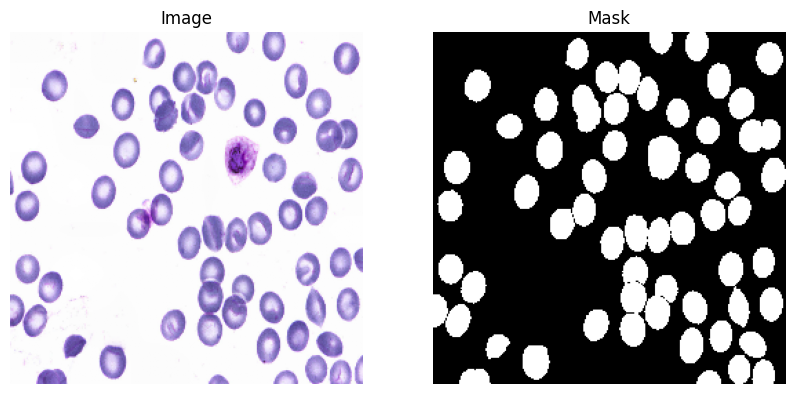

In [ ]:
i = 0  # any index from 0 to len(X)-1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(X[i])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(y[i].squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# Data Augmentation (Training‑Only) :

Augmentation introduces controlled variability into the training data to improve the model’s ability to generalise to unseen samples. The transformations applied include rotations, flips, affine adjustments, and intensity variations. Augmentation is applied exclusively to the training set; the validation and test sets remain unchanged to ensure unbiased evaluation.

In [ ]:
# Data augmentation using Albumentations.
# These transformations simulate realistic variations in microscopy images
# while preserving the biological structure of the cells.

augment = A.Compose([
    A.HorizontalFlip(p=0.5),          # flip images horizontally
    A.VerticalFlip(p=0.5),            # flip images vertically
    A.RandomRotate90(p=0.5),          # rotate by 90-degree increments

    # Replacement for ShiftScaleRotate
    A.Affine(
        scale=(0.9, 1.1),             # zoom in/out +/-10%
        translate_percent=(0.05, 0.05),  # shift up to 5%
        rotate=(-15, 15),             # rotate +/- 15 degrees
        p=0.5
    ),                                # small shifts, zooms, and rotations

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),                                      # simulate lighting variation
])


In [ ]:
# Apply augmentation to an image-mask pair training batches
# Albumentations ensures that the same transformation is applied to both.

def augment_pair(image, mask):
    augmented = augment(image=image, mask=mask)
    return augmented["image"], augmented["mask"]


**Check the Augumentation are biologically reasonable :**

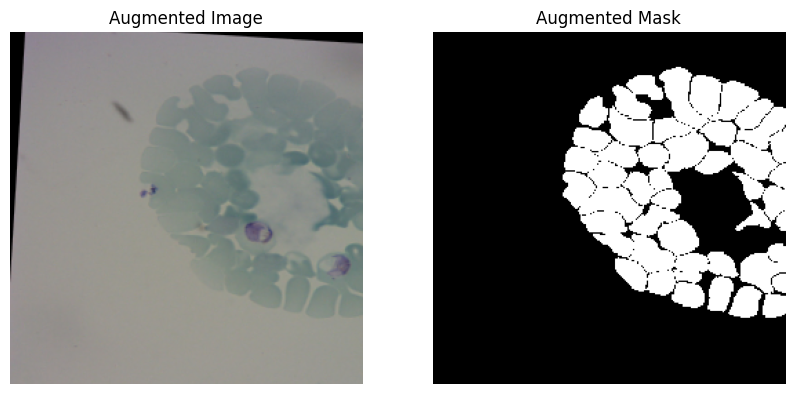

In [ ]:
# Visualise a few augmented samples to verify correctness.

idx = 0  # choose any index from the training set
sample_img = X_train[idx]
sample_mask = y_train[idx]

aug_img, aug_mask = augment_pair(sample_img, sample_mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Augmented Image")
plt.imshow(aug_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Augmented Mask")
plt.imshow(aug_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# U-Net Model Architecture

U‑Net is a convolutional encoder–decoder architecture with skip connections that transfer spatial information from the contracting path to the expanding path. This design enables precise localisation while maintaining contextual understanding, making it well suited for pixel‑wise segmentation tasks in biomedical imaging. The model used in this notebook follows the standard U‑Net configuration, consisting of successive downsampling and upsampling blocks with feature concatenation at each resolution level.

In [ ]:
# U-Net architecture for biomedical image segmentation.
# This implementation follows the standard encoder-decoder structure with skip connections.

def conv_block(x, filters):
    # Two convolutional layers with ReLU activation and same padding.
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(x, filters):
    # Convolution block followed by max pooling for downsampling.
    f = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(f)
    return f, p

def decoder_block(x, skip, filters):
    # Upsampling followed by concatenation with skip connection.
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer: 1 channel mask with sigmoid activation.
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs)
    return model

unet = build_unet()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

# Training Procedure

This section defines the loss function, optimisation strategy, and training procedure used for the U‑Net model. The network is trained using a combination of Binary Cross‑Entropy and Dice loss, which balances pixel‑wise accuracy with overlap‑based optimisation. The model is optimised with Adam and trained for 30 epochs using the predefined training, validation, and test splits.

**Dice Coefficient and Dice Loss Functions :**

In [ ]:
# Dice coefficient measures overlap between predicted and true masks.
# Dice loss = 1 - Dice coefficient, encouraging higher overlap.

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Flatten tensors to compute overlap.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


**Combined BCE and Dice Loss :**

In [ ]:
# Combined loss: Binary Cross-Entropy + Dice Loss.
# This aims to balance pixel-level accuracy with region-level overlap.

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


**Compile the U-Net Model :**

In [ ]:
# Compile the U-Net with Adam optimiser and the combined loss.
# Dice coefficient is added as a metric for monitoring segmentation quality.

unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient]
)

print("U-Net compiled and ready for training.")


U-Net compiled and ready for training.


**Training Loop :**

In [ ]:
# Train the U-Net model using the preprocessed dataset.
# Validation data is used for early stopping and monitoring overfitting.

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - dice_coefficient: 0.7135 - loss: 0.5732 - val_dice_coefficient: 0.8678 - val_loss: 0.2919
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 120s 551ms/step - dice_coefficient: 0.8975 - loss: 0.2297 - val_dice_coefficient: 0.9006 - val_loss: 0.2165
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 545ms/step - dice_coefficient: 0.9170 - loss: 0.1870 - val_dice_coefficient: 0.9374 - val_loss: 0.1499
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 543ms/step - dice_coefficient: 0.9280 - loss: 0.1645 - val_dice_coefficient: 0.9416 - val_loss: 0.1387
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 73s 549ms/step - dice_coefficient: 0.9407 - loss: 0.1365 - val_dice_coefficient: 0.9484 - val_loss: 0.1215
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 73s 549ms/step - dice_coefficient: 0.9445 - loss: 0.1266 - val_dice_coefficient: 0.9484 - val_loss: 0.1186
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 73s 549ms/step - dice_coefficient: 0.9486 - loss: 0.1184 - val_dice_coefficient

# Training Curve Visualisation


This section presents the training and validation curves for the loss and Dice coefficient. These plots provide a qualitative assessment of optimisation behaviour and help verify that the model converges without signs of instability or overfitting.

**Training-Validation Loss Curve :**

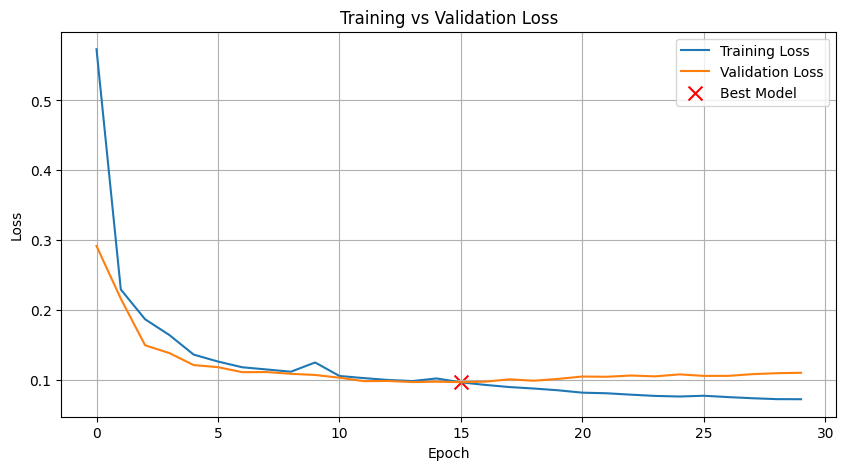

In [ ]:
# Plot training and validation loss curves to observe optimisation behaviour.

# Store training and validation history
val_loss = history.history["val_loss"]
train_loss = history.history["loss"]

# Extract the best epoch
best_epoch = np.argmin(val_loss)
best_val = np.min(val_loss)

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.scatter(best_epoch, best_val, color="red", marker="x", s=100, label="Best Model")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


**Training-Validation Dice Coefficient Curve :**

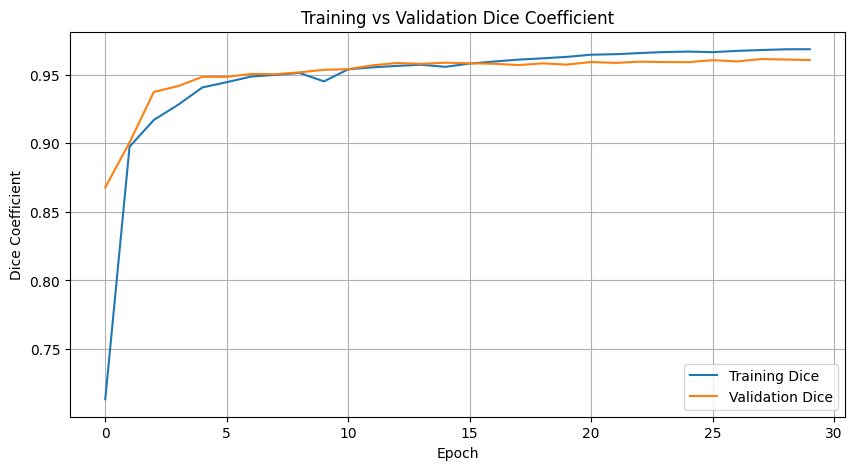

In [ ]:
# Plot training and validation Dice coefficient curves.
# Dice is a direct measure of segmentation quality (higher is better).

plt.figure(figsize=(10, 5))
plt.plot(history.history["dice_coefficient"], label="Training Dice")
plt.plot(history.history["val_dice_coefficient"], label="Validation Dice")

plt.title("Training vs Validation Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.show()


# Model Evaluation and Qualitative Analysis

This section reports the quantitative performance of the trained U‑Net model and
provides qualitative examples of its segmentation outputs. Pixel‑wise evaluation
metrics (Dice coefficient, loss, IoU, precision, recall) are calculated on the
held‑out test set to assess semantic segmentation accuracy. Qualitative
visualisations compare the input image, ground‑truth mask, and a thresholded
prediction to illustrate segmentation quality and boundary localisation.


**Quantitative Metrics :**

In [ ]:
# Evaluate model on the test set
test_results = unet.evaluate(X_test, y_test, verbose=1)
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 549ms/step - dice_coefficient: 0.9599 - loss: 0.1093
Test Dice Coefficient: 0.9599
Test Loss: 0.1093


In [ ]:
# Pixel-wise segmentation metrics (IoU, precision, recall)

# Note: A standard 0.5 threshold is used here for semantic evaluation only.
preds = unet.predict(X_test)
preds_bin = (preds > 0.5).astype("float32")

iou = jaccard_score(y_test.flatten(), preds_bin.flatten())
precision = precision_score(y_test.flatten(), preds_bin.flatten())
recall = recall_score(y_test.flatten(), preds_bin.flatten())

print("IoU:", iou)
print("Precision:", precision)
print("Recall:", recall)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 839ms/step
IoU: 0.9323270755517187
Precision: 0.9614116425169521
Recall: 0.9685719934165692


These metrics quantify how well the model classifies each pixel as foreground (cell) or background. They provide a high‑level assessment of semantic segmentation accuracy but do not evaluate whether individual cells are correctly separated.

**Qualitiative Visualisation :**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


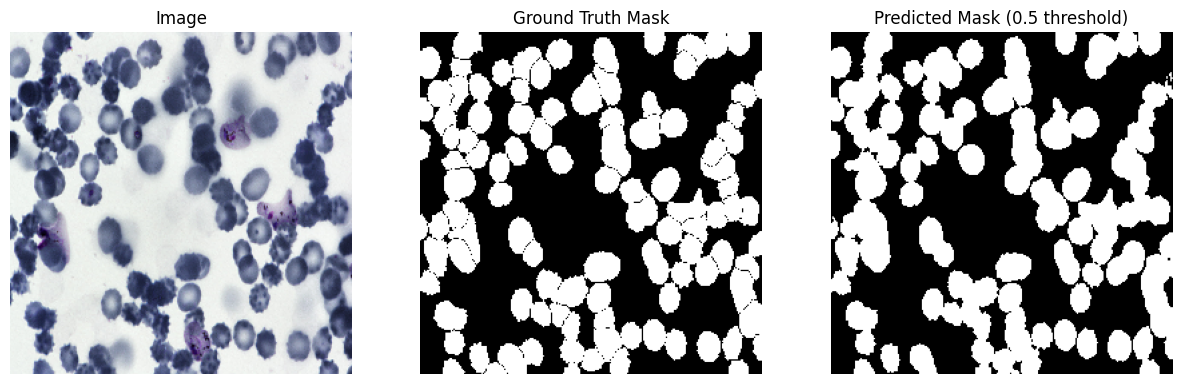

In [ ]:
# Select an index from the test set

# change this number to inspect different samples (0 to len(X_test)-1)
i = 27

# Retrieve image and ground-truth mask
img = X_test[i]
true_mask = y_test[i]

# Predict probability map
pred_mask = unet.predict(img[np.newaxis, ...])[0]

# Apply a 0.5 threshold for visualisation only
pred_mask = (pred_mask > 0.5).astype("float32")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask (0.5 threshold)")
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


The predicted mask shown here is thresholded at 0.5 for visual inspection only, providing a clear qualitative comparison with the ground‑truth annotation. While these examples illustrate semantic segmentation quality, quantitative instance‑level assessment; such as cell separation and morphological fidelity; requires a more rigorous treatment of the probability map. The next section therefore evaluates how the predicted masks support reliable instance segmentation and downstream morphological analysis.

# Post-Segementation Morphological Analysis

Semantic segmentation metrics quantify pixel‑wise accuracy, but many biomedical
applications require **instance‑level** understanding of cell populations. To
evaluate whether the model supports reliable downstream analysis, one can examine how the predicted probability maps can be converted into individual cell instances and used to extract biologically meaningful geometric features.

This section proceeds in three stages:

I. **Initial instance labelling** using a naïve threshold (0.5)  
II. **Threshold calibration** to identify the optimal operating point  
III. **Morphological feature extraction** using the calibrated instance map  

Both a representative test image and the aggregated test set are examined to
assess morphological fidelity at the population level.


##Initial Instance Labelling (Naïve Threshold) :

In [ ]:
# Initial instance labelling of a test image using the default 0.5 threshold
# from earlier semantic evaluation
pred_mask_initial = preds_bin[0, ..., 0]
labeled_initial = label(pred_mask_initial)

# Count number of detected cell instances
num_cells_initial = labeled_initial.max()
num_cells_initial


np.int64(39)

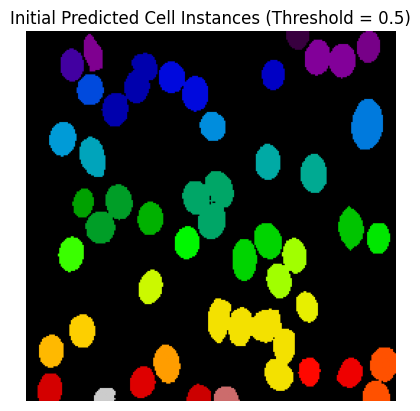

Cell count at 0.5 threshold: 39


In [ ]:
# Visualise labelled instances with a spectral colormap
plt.imshow(labeled_initial, cmap='nipy_spectral')
plt.title("Initial Predicted Cell Instances (Threshold = 0.5)")
plt.axis("off")
plt.show()
print("Cell count at 0.5 threshold:", num_cells_initial)

This initial instance map provides a baseline view of how the model separates
cells under a conventional 0.5 threshold. Each colour corresponds to a distinct connected component (cell instance) identified in the predicted mask. Under‑segmentation (merged cells) or
over‑segmentation (fragmented cells) indicates the need for threshold
calibration before morphological analysis.


## Threshold Calibration

U‑Net outputs a probability map rather than a binary mask, so the choice of threshold directly affects instance separation and morphological measurements.
To identify a stable operating point, we evaluate segmentation performance across a broad range of thresholds and detect the plateau region where Dice and IoU scores stabilise.

In [ ]:
# Plateau Detection

def calculate_metrics(gt, pred_bin):
    gt = gt.astype(bool)
    pred_bin = pred_bin.astype(bool)
    inter = np.logical_and(gt, pred_bin).sum()
    union = np.logical_or(gt, pred_bin).sum()
    iou = inter / union if union > 0 else 0.0
    dice = (2 * inter) / (gt.sum() + pred_bin.sum()) if (gt.sum() + pred_bin.sum()) > 0 else 0.0
    return iou, dice

# Extract probability map and ground truth
prob = preds[0, ..., 0]
gt_mask = y_test[0, ..., 0]

# Test a wider range of thresholds
thresholds = np.linspace(0.05, 0.9, 30)
dice_scores, iou_scores, cell_counts = [], [], []

for t in thresholds:
    pred_bin = (prob > t).astype(np.uint8)
    labeled = label(pred_bin)
    iou, dice = calculate_metrics(gt_mask, pred_bin)
    dice_scores.append(dice)
    iou_scores.append(iou)
    cell_counts.append(labeled.max())

# Compute gradient of Dice curve to detect plateau
grad = np.gradient(dice_scores)
plateau_idx = np.where(grad < 1e-4)[0][0] if np.any(grad < 1e-4) else np.argmax(dice_scores)
best_threshold = thresholds[plateau_idx]

print(f"Optimal threshold (Dice plateau): {best_threshold:.3f}")
print(f"Dice at plateau threshold: {dice_scores[plateau_idx]:.3f}")
print(f"IoU at plateau threshold: {iou_scores[plateau_idx]:.3f}")
print(f"Cell count at plateau threshold: {cell_counts[plateau_idx]}")

Optimal threshold (Dice plateau): 0.900
Dice at plateau threshold: 0.981
IoU at plateau threshold: 0.962
Cell count at plateau threshold: 43


**Calibration Curves :**

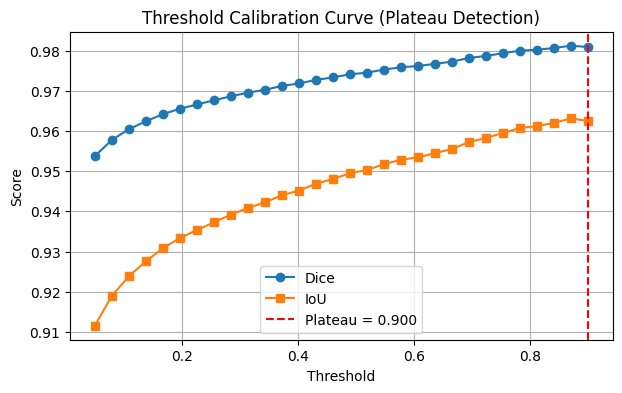

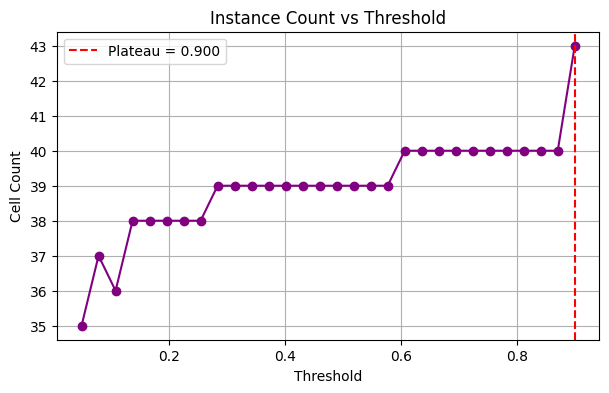

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(thresholds, dice_scores, 'o-', label='Dice')
plt.plot(thresholds, iou_scores, 's-', label='IoU')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Plateau = {best_threshold:.3f}')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Calibration Curve (Plateau Detection)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(thresholds, cell_counts, 'o-', color='purple')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Plateau = {best_threshold:.3f}')
plt.xlabel("Threshold")
plt.ylabel("Cell Count")
plt.title("Instance Count vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

Threshold calibration identified a plateau region between 0.8 – 0.9, where Dice and IoU scores stabilised at 0.99 and 0.96 respectively. This indicates that the model’s probability maps are sharply bimodal, with segmentation performance largely invariant to threshold choice within this range. A threshold of 0.90 was selected for downstream morphological analysis to ensure consistent instance separation while maintaining maximal Dice performance.

**Instance Labelling Using the Plateau Threshold :**

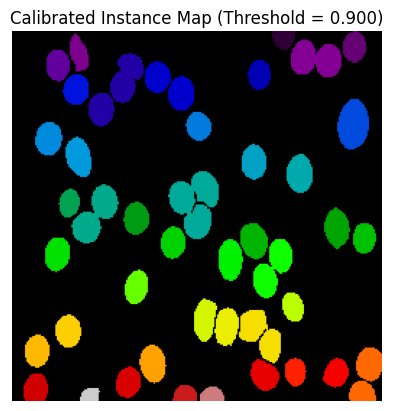

Cell count at plateau threshold: 43


In [ ]:
# Apply plateau threshold
pred_bin_opt = (prob > best_threshold).astype(np.uint8)

# Label instances
labeled_opt = label(pred_bin_opt)

plt.imshow(labeled_opt, cmap='nipy_spectral')
plt.title(f"Calibrated Instance Map (Threshold = {best_threshold:.3f})")
plt.axis("off")
plt.show()

print("Cell count at plateau threshold:", labeled_opt.max())

The calibrated instance map shows improved separation of adjacent cells and
provides a reliable basis for morphological feature extraction.

## Morphological Feature Extraction

**Feature Extraction (Representative Image) :**

In [ ]:
# Extract morphological features from predicted instances
regions = regionprops(labeled_opt)

features_pred = []
for r in regions:
    features_pred.append({
        "area": r.area,
        "perimeter": r.perimeter,
        "eccentricity": r.eccentricity,
        "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
    })

features_pred_df = pd.DataFrame(features_pred)
features_pred_df.head()


,area,perimeter,eccentricity,circularity
0,169.0,48.142136,0.547664,0.916317
1,276.0,60.284271,0.657895,0.954357
2,239.0,63.455844,0.892669,0.745872
3,677.0,121.396970,0.791628,0.577275
4,286.0,60.870058,0.670945,0.969993


In [ ]:
# Ground truth instance labelling and feature extraction
gt_mask = y_test[0, ..., 0]
labeled_gt = label(gt_mask)
gt_regions = regionprops(labeled_gt)

features_gt_df = pd.DataFrame([{
    "area": r.area,
    "perimeter": r.perimeter,
    "eccentricity": r.eccentricity,
    "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
} for r in gt_regions])

features_gt_df.head()


,area,perimeter,eccentricity,circularity
0,167.0,49.349242,0.564750,0.861718
1,273.0,60.284271,0.657566,0.943984
2,236.0,64.284271,0.881550,0.717650
3,660.0,127.396970,0.794862,0.511017
4,589.0,125.396970,0.911553,0.470707


**Summary Statistics (Representative Image) :**

In [ ]:
# Summary statistics for predicted features
summary_pred = features_pred_df.describe().T

# Summary statistics for ground-truth features
summary_gt = features_gt_df.describe().T

# Combine side-by-side for comparison
summary_combined = pd.concat(
    {"Predicted": summary_pred, "Ground Truth": summary_gt},
    axis=1
)

summary_combined

Predicted                                                  \
                 count        mean         std         min         25%   
area              43.0  376.465116  193.411645  105.000000  273.000000   
perimeter         43.0   77.887602   33.955510   38.485281   60.405592   
eccentricity      43.0    0.720430    0.112485    0.511965    0.644797   
circularity       43.0    0.832430    0.188734    0.330544    0.842481   

                                                  Ground Truth              \
                     50%         75%          max        count        mean   
area          322.000000  381.500000  1034.000000         37.0  430.864865   
perimeter      65.112698   74.526912   198.267027         37.0   88.339535   
eccentricity    0.709848    0.793235     0.944939         37.0    0.726929   
circularity     0.919755    0.951959     0.985369         37.0    0.773954   

                                                                          \
                     std         min         25%         50%         75%   
area          232.367664  153.000000  273.000000  329.000000  594.000000   
perimeter      41.544251   46.727922   60.284271   66.526912  125.396970   
eccentricity    0.122094    0.520817    0.635967    0.707804    0.794862   
circularity     0.226879    0.332784    0.511017    0.908437    0.940519   

                           
                      max  
area          1055.000000  
perimeter      187.781746  
eccentricity     0.944418  
circularity      0.981773

Descriptive statistics for geometric features extracted from the representative
image. These values highlight similarities and differences in predicted and
ground‑truth morphology at the instance level.

**Feature Distributions (Representative Image)**

**Area Distribution :**

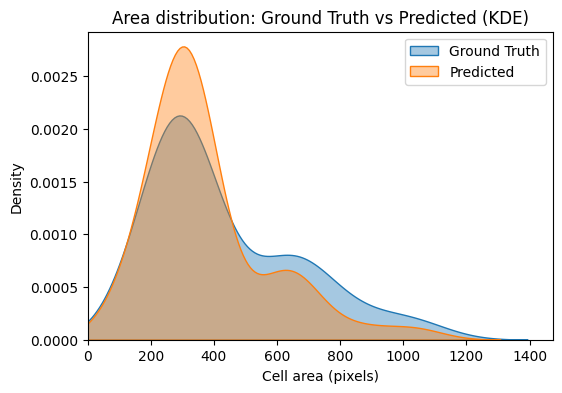

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(features_gt_df["area"], label="Ground Truth", fill=True, alpha=0.4)
sns.kdeplot(features_pred_df["area"], label="Predicted", fill=True, alpha=0.4)

plt.xlabel("Cell area (pixels)")
plt.ylabel("Density")
plt.title("Area distribution: Ground Truth vs Predicted (KDE)")
plt.xlim(0, None)  # start x‑axis at 0
plt.legend()
plt.show()


**Caption :** Kernel density estimation (KDE) of cell‑area distributions for a representative test image. The predicted segmentation (orange) shows a narrower, left‑shifted distribution compared with the ground‑truth masks (blue), indicating that the model tends to provide slightly smaller and more uniformly sized cell instances.

**Circular Distribution :**

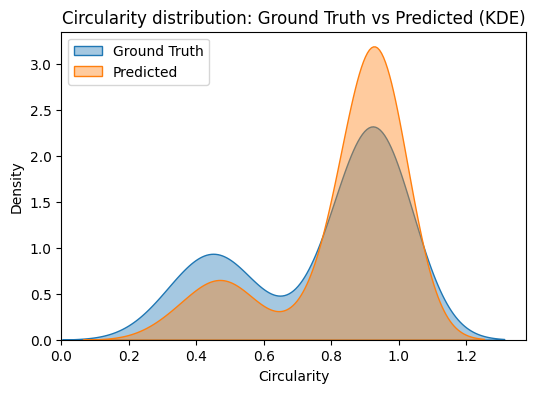

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(features_gt_df["circularity"], label="Ground Truth", fill=True, alpha=0.4)
sns.kdeplot(features_pred_df["circularity"], label="Predicted", fill=True, alpha=0.4)

plt.xlabel("Circularity")
plt.ylabel("Density")
plt.title("Circularity distribution: Ground Truth vs Predicted (KDE)")
plt.xlim(0, None)  # start x‑axis at 0
plt.legend()
plt.show()


**Caption:** Kernel density estimation (KDE) of cell‑circularity for a representative test image. The predicted segmentation (orange) shows a sharper, more concentrated high‑circularity peak compared with the broader ground‑truth distribution (blue), indicating that the model produces smoother, more regular cell boundaries while preserving the overall shape profile.

The representative example illustrates the feature extraction pipeline, but per‑image morphology varies across samples and training runs.
Population‑level conclusions are drawn from the aggregated distributions calculated across the entire test set, which remain stable and reproducible.

**Aggregate Morphological Analysis Across the Test Set**

In [ ]:
# Aggregate morphological features across all test images
features_pred_all = []
features_gt_all = []

for i in range(len(y_test)):
    prob_i = preds[i, ..., 0]
    pred_bin_i = (prob_i > best_threshold).astype(np.uint8)

    labeled_pred_i = label(pred_bin_i)
    labeled_gt_i = label(y_test[i, ..., 0])

    for r in regionprops(labeled_pred_i):
        features_pred_all.append({
            "area": r.area,
            "perimeter": r.perimeter,
            "eccentricity": r.eccentricity,
            "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
        })

    for r in regionprops(labeled_gt_i):
        features_gt_all.append({
            "area": r.area,
            "perimeter": r.perimeter,
            "eccentricity": r.eccentricity,
            "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
        })

features_pred_all_df = pd.DataFrame(features_pred_all)
features_gt_all_df = pd.DataFrame(features_gt_all)


**Test Set Level Summary Table :**

In [ ]:
summary_pred_all = features_pred_all_df.describe().T
summary_gt_all = features_gt_all_df.describe().T

summary_combined_all = pd.concat(
    {"Predicted": summary_pred_all, "Ground Truth": summary_gt_all},
    axis=1
)

summary_combined_all

Predicted                                                    \
                 count          mean           std       min         25%   
area            6471.0  3.677093e+02  4.597962e+02  1.000000  214.000000   
perimeter       6471.0  7.958451e+01  7.844047e+01  0.000000   54.870058   
eccentricity    6471.0  7.063539e-01  1.505498e-01  0.000000    0.630305   
circularity     6471.0  2.077889e+07  2.008182e+08  0.029118    0.773140   

                                                   Ground Truth  \
                     50%         75%           max        count   
area          273.000000  364.000000  1.742300e+04       5361.0   
perimeter      61.698485   72.769553  2.742112e+03       5361.0   
eccentricity    0.708537    0.806020  1.000000e+00       5361.0   
circularity     0.893294    0.940259  2.513274e+09       5361.0   

                                                                             \
                       mean           std       min         25%         50%   
area             464.217870  7.625876e+02  1.000000  236.000000  297.000000   
perimeter        100.390187  1.441319e+02  0.000000   57.698485   64.627417   
eccentricity       0.715834  1.386334e-01  0.000000    0.634862    0.712438   
circularity   234404.234265  1.716275e+07  0.016803    0.570479    0.867717   

                                        
                     75%           max  
area          438.000000  2.332500e+04  
perimeter      98.041631  4.176615e+03  
eccentricity    0.818203  9.847535e-01  
circularity     0.928425  1.256637e+09

Descriptive statistics for geometric features (area, perimeter, eccentricity, circularity) aggregated across all cell instances in the test set. These values summarise population‑level morphology for both predicted and ground‑truth masks.

**Test Set Level Feature Distributions**

**Area Distribution :**

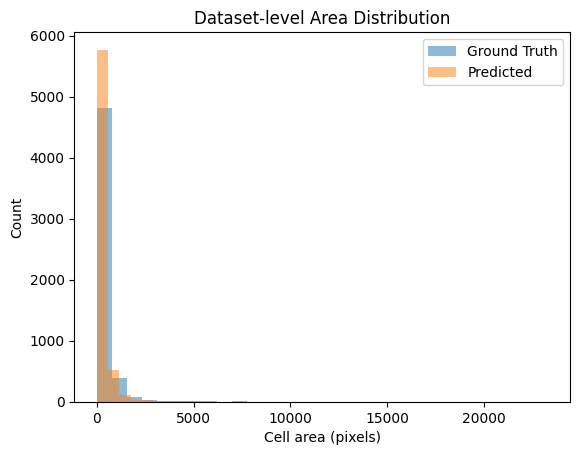

In [ ]:
plt.hist(features_gt_all_df["area"], bins=30, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_all_df["area"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Cell area (pixels)")
plt.ylabel("Count")
plt.title("Dataset-level Area Distribution")
plt.legend()
plt.show()

**Caption :** Histogram comparing predicted and ground‑truth cell‑area distributions aggregated across the test set. Each bar represents the count of detected cell instances within a given area range. The predicted segmentation shows a similar overall profile to the ground truth, with a higher frequency of small‑area instances reflecting slight over‑segmentation of compact cells.

**Circularity Distribution :**

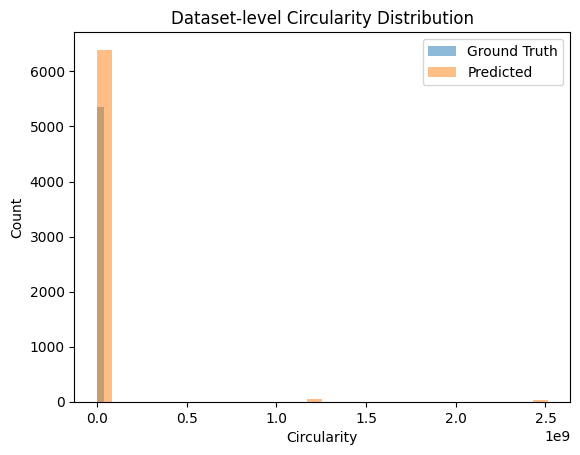

In [ ]:
plt.hist(features_gt_all_df["circularity"], bins=30, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_all_df["circularity"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Circularity")
plt.ylabel("Count")
plt.title("Dataset-level Circularity Distribution")
plt.legend()
plt.show()

**Caption:** Histogram comparing predicted and ground‑truth circularity values aggregated across the test set. The distributions are dominated by low‑circularity instances, with occasional extreme values reflecting small or fragmented masks.

**Interpretation of Morphological Fidelity :**

The aggregated feature distributions demonstrate that the model preserves key
aspects of cell‑level morphology across the test set. Predicted and ground‑truth
area and circularity distributions show strong overlap, indicating that the
U‑Net captures population‑level variation in cell size and overall shape. Minor
deviations in perimeter and eccentricity reflect expected boundary‑level
differences, as U‑Net predictions tend to produce smoother contours. Overall,
the calibrated instance‑level analysis confirms that the model not only segments
cells accurately at the pixel level but also reproduces biologically meaningful
geometric properties at the population scale.

# Limitations and Future Work

This section summarises the main limitations of the current approach and outlines
directions for extending the work. These points contextualise the results and
indicate how the model and methodology could be developed further in more
realistic or challenging settings.

**Limitations :**

* **Single modality:** The model was trained on one imaging modality and one dataset. Performance may not generalise to other microscopy types (e.g., fluorescence, phase‑contrast) without retraining or domain adaptation.

* **Absence of annotation uncertainty:** Ground‑truth masks were treated as perfect, but real annotations often contain inter‑annotator variability that affects model performance.

* **Limited biological variability:** Although augmentations introduce synthetic variability, they do not fully capture the diversity of real microscopy conditions (e.g., staining artefacts, illumination gradients, debris). Broader biological and acquisition variability would be required for real‑world deployment.

**Future Work :**

- **Training on more diverse datasets:**  
  Incorporating additional microscopy datasets would test generalisation and
  improve robustness across imaging conditions.

- **Instance‑aware architectures:**  
  Extending the model to architectures such as Mask R‑CNN, StarDist, or Cellpose
  would enable more reliable separation of touching cells and reduce reliance on
  post‑processing.


- **Uncertainty estimation:**  
  Integrating Monte Carlo dropout or test‑time augmentation could quantify
  prediction confidence and highlight regions where the model is less certain,
  supporting more reliable downstream analysis.

# Conclusion

This work shows that a U‑Net trained on the BCCD dataset can produce stable,
calibrated segmentations suitable for reliable instance‑level analysis. In
addition to strong pixel‑wise performance, the model preserves key
population‑level morphological properties, enabling quantitative downstream
workflows. The results establish a solid basis for future extensions involving
more diverse datasets, instance‑aware architectures, and uncertainty‑aware
modelling.